In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx
import json
from ipysigma import Sigma

Text(0.5, 1.0, 'Databases Redudancy (>95% identity)')

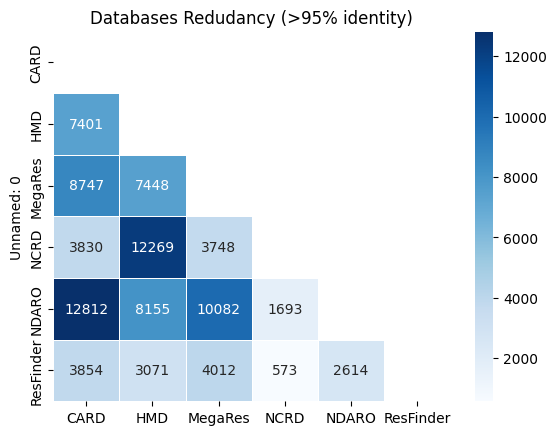

In [94]:
BlastPairWiseAlignmentPivoted = pd.read_csv("../data/processed/BlastPairWiseAlignmentPivoted.cov80.maxseq1.csv", sep="\t")
mask = np.triu(np.ones_like(BlastPairWiseAlignmentPivoted.set_index("Unnamed: 0"), dtype=bool)) 
sns.heatmap(
    BlastPairWiseAlignmentPivoted.set_index("Unnamed: 0"),
    cmap="Blues",
    annot=True,
    fmt=".0f",
    linewidth=.5,
    mask=mask,
)
plt.title("Databases Redudancy (>95% identity)")

In [95]:
BlastPairWiseAlignmentPivoted

,Unnamed: 0,CARD,HMD,MegaRes,NCRD,NDARO,ResFinder
0,CARD,5288,5237,7229,1466,7695,2212
1,HMD,7401,29172,7869,6302,5963,2668
2,MegaRes,8747,7448,4630,1582,6716,3191
3,NCRD,3830,12269,3748,17242,2844,811
4,NDARO,12812,8155,10082,1693,6647,2835
5,ResFinder,3854,3071,4012,573,2614,305


Text(0, 0.5, 'Database Size')

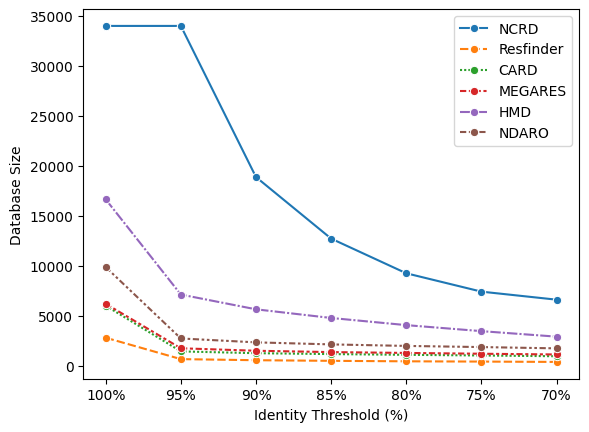

In [96]:
ClustersCdHit = pd.read_csv(
    "../data/processed/cdhitclusters.defaultsettings.csv",
    sep = "\t",
)
sns.lineplot(
    ClustersCdHit.set_index("Unnamed: 0"),
    marker = "o"
)
plt.xlabel("Identity Threshold (%)")
plt.ylabel("Database Size")

In [97]:
ClustersCdHit

,Unnamed: 0,NCRD,Resfinder,CARD,MEGARES,HMD,NDARO
0,100%,34008,2830,6027,6220,16666,9892
1,95%,34008,690,1462,1774,7147,2755
2,90%,18893,580,1283,1527,5670,2366
3,85%,12739,519,1194,1393,4805,2162
4,80%,9273,471,1120,1308,4089,2010
5,75%,7437,444,1053,1228,3487,1895
6,70%,6634,410,978,1155,2937,1766


In [98]:
PairWiseAlignment = pd.read_csv(
    "../data/filtered/AllDatabases.Paiwise.cov80.maxseq1.tsv", 
    sep = "\t",
    skipinitialspace=True, 
    header=None,
    names = "qseqid sseqid pident length qlen slen qstart qend sstart send evalue bitscore ppos full_qseq full_sseq".split(" ")
)
PairWiseAlignment["qcov"] = np.round((PairWiseAlignment["qend"] - PairWiseAlignment["qstart"] + 1) / (PairWiseAlignment["qlen"]) * 100, 2)
PairWiseAlignment["scov"] = np.round((PairWiseAlignment["send"] - PairWiseAlignment["sstart"] + 1) / (PairWiseAlignment["slen"]) * 100, 2)
PairWiseAlignment["qseqtag"] = PairWiseAlignment["qseqid"].str.split("|").str[1]
PairWiseAlignment["sseqtag"] = PairWiseAlignment["sseqid"].str.split("|").str[1]
PairWiseAlignment["qseqid"] = PairWiseAlignment["qseqid"].str.split("|").str[0]
PairWiseAlignment["sseqid"] = PairWiseAlignment["sseqid"].str.split("|").str[0]

In [99]:
PairWiseAlignment

,qseqid,sseqid,pident,length,qlen,slen,qstart,qend,sstart,send,evalue,bitscore,ppos,full_qseq,full_sseq,qcov,scov,qseqtag,sseqtag
0,CARD_0,MEGARES_1086,100.0,296,296,296,1,296,1,296,5.700000e-215,587.0,100.0,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,100.0,100.0,CARD,MEGARES
1,CARD_1,HMD_829,100.0,286,286,286,1,286,1,286,3.950000e-201,551.0,100.0,MRYIRLCIISLLAALPLAVHASPQPLEQIKQSESQLSGRVGMIEMD...,MRYIRLCIISLLAALPLAVHASPQPLEQIKQSESQLSGRVGMIEMD...,100.0,100.0,CARD,HMD
2,CARD_2,NCRD_0,100.0,164,164,164,1,164,1,164,3.190000e-117,328.0,100.0,MIGLIVARSKNNVIGKNGNIPWKIKGEQKQFRELTTGNVVIMGRKS...,MIGLIVARSKNNVIGKNGNIPWKIKGEQKQFRELTTGNVVIMGRKS...,100.0,100.0,CARD,NCRD
3,CARD_3,HMD_1374,100.0,291,291,291,1,291,1,291,6.060000e-203,556.0,100.0,MVTKRVQRMMFAAAACIPLLLGSAPLYAQTSAVQQKLAALEKSSGG...,MVTKRVQRMMFAAAACIPLLLGSAPLYAQTSAVQQKLAALEKSSGG...,100.0,100.0,CARD,HMD
4,CARD_4,HMD_247,100.0,270,270,270,1,270,1,270,2.890000e-195,535.0,100.0,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,100.0,100.0,CARD,HMD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76568,RESFINDER_2918,CARD_4513,100.0,539,539,539,1,539,1,539,0.000000e+00,1078.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD
76569,RESFINDER_2919,CARD_4474,100.0,539,539,539,1,539,1,539,0.000000e+00,1078.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD
76570,RESFINDER_2920,CARD_4512,100.0,539,539,539,1,539,1,539,0.000000e+00,1078.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD
76571,RESFINDER_2921,CARD_4473,100.0,539,539,539,1,539,1,539,0.000000e+00,1077.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD


<Axes: xlabel='qcov', ylabel='pident'>

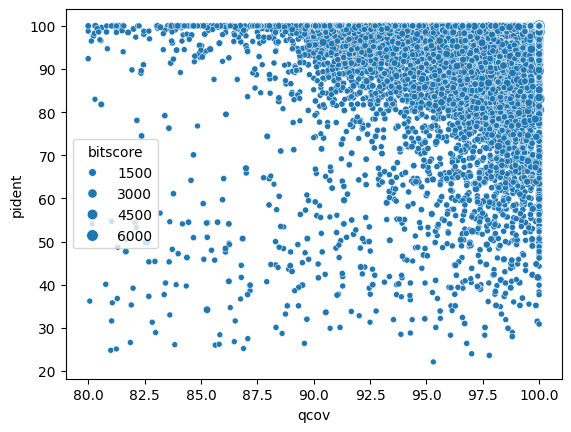

In [100]:
sns.scatterplot(
    data=PairWiseAlignment.loc[PairWiseAlignment["bitscore"] > 50], 
    x="qcov", 
    y="pident",
    size = "bitscore",
    )

<Axes: xlabel='pident', ylabel='ppos'>

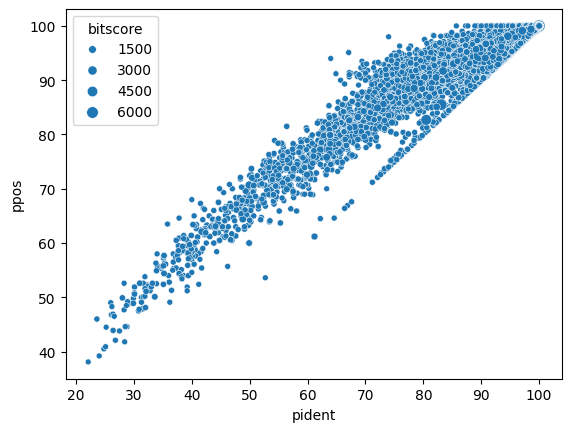

In [101]:
sns.scatterplot(
    data=PairWiseAlignment.loc[PairWiseAlignment["bitscore"] > 50], 
    x="pident", 
    y="ppos",
    size = "bitscore",
    )

In [102]:
PairWiseAlignment

,qseqid,sseqid,pident,length,qlen,slen,qstart,qend,sstart,send,evalue,bitscore,ppos,full_qseq,full_sseq,qcov,scov,qseqtag,sseqtag
0,CARD_0,MEGARES_1086,100.0,296,296,296,1,296,1,296,5.700000e-215,587.0,100.0,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,100.0,100.0,CARD,MEGARES
1,CARD_1,HMD_829,100.0,286,286,286,1,286,1,286,3.950000e-201,551.0,100.0,MRYIRLCIISLLAALPLAVHASPQPLEQIKQSESQLSGRVGMIEMD...,MRYIRLCIISLLAALPLAVHASPQPLEQIKQSESQLSGRVGMIEMD...,100.0,100.0,CARD,HMD
2,CARD_2,NCRD_0,100.0,164,164,164,1,164,1,164,3.190000e-117,328.0,100.0,MIGLIVARSKNNVIGKNGNIPWKIKGEQKQFRELTTGNVVIMGRKS...,MIGLIVARSKNNVIGKNGNIPWKIKGEQKQFRELTTGNVVIMGRKS...,100.0,100.0,CARD,NCRD
3,CARD_3,HMD_1374,100.0,291,291,291,1,291,1,291,6.060000e-203,556.0,100.0,MVTKRVQRMMFAAAACIPLLLGSAPLYAQTSAVQQKLAALEKSSGG...,MVTKRVQRMMFAAAACIPLLLGSAPLYAQTSAVQQKLAALEKSSGG...,100.0,100.0,CARD,HMD
4,CARD_4,HMD_247,100.0,270,270,270,1,270,1,270,2.890000e-195,535.0,100.0,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,100.0,100.0,CARD,HMD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76568,RESFINDER_2918,CARD_4513,100.0,539,539,539,1,539,1,539,0.000000e+00,1078.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD
76569,RESFINDER_2919,CARD_4474,100.0,539,539,539,1,539,1,539,0.000000e+00,1078.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD
76570,RESFINDER_2920,CARD_4512,100.0,539,539,539,1,539,1,539,0.000000e+00,1078.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD
76571,RESFINDER_2921,CARD_4473,100.0,539,539,539,1,539,1,539,0.000000e+00,1077.0,100.0,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,MPVLFRMRVIPLVLLLALVFAFLLNWPVLLHFYDILSRLEHVRAGF...,100.0,100.0,RESFINDER,CARD


In [103]:
with open("../data/processed/MetaDict.Cov80.maxseq1.json", "r") as json_file  :
    MetaDict = json.load(json_file)

In [104]:
MetaDict["CARD_0"]

{'Drug Class': 'beta-lactam',
 'Name': 'CblA-1',
 'Sequence': 'MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAVWTDKGDMLRYNDHVHFPLLSVFKFHVALAVLDKMDKQSISLDSIVSIKASQMPPNTYSPLRKKFPDQDFTITLRELMQYSISQSDNNACDILIEYAGGIKHINDYIHRLSIDSFNLSETEDGMHSSFEAVYRNWSTPSAMVRLLRTADEKELFSNKELKDFLWQTMIDTETGANKLKGMLPAKTVVGHKTGSSDRNADGMKTADNDAGLVILPDGRKYYIAAFVMDSYETDEDNANIIARISRMVYDAMR'}

In [105]:
SequenceSimilarityGraph = nx.from_pandas_edgelist(
    PairWiseAlignment.loc[PairWiseAlignment["bitscore"] > 50], 
    source="qseqid", 
    target="sseqid", 
    edge_attr=["pident", "bitscore", "evalue","bitscore", "ppos"]
)

In [106]:
nx.set_node_attributes(SequenceSimilarityGraph, MetaDict)

In [107]:
SequenceSimilarityGraph.nodes["CARD_0"]

{'Drug Class': 'beta-lactam',
 'Name': 'CblA-1',
 'Sequence': 'MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAVWTDKGDMLRYNDHVHFPLLSVFKFHVALAVLDKMDKQSISLDSIVSIKASQMPPNTYSPLRKKFPDQDFTITLRELMQYSISQSDNNACDILIEYAGGIKHINDYIHRLSIDSFNLSETEDGMHSSFEAVYRNWSTPSAMVRLLRTADEKELFSNKELKDFLWQTMIDTETGANKLKGMLPAKTVVGHKTGSSDRNADGMKTADNDAGLVILPDGRKYYIAAFVMDSYETDEDNANIIARISRMVYDAMR'}

In [108]:
ConnectedComponents = list(nx.connected_components(SequenceSimilarityGraph))
len(ConnectedComponents)

16598

In [109]:
ProblematicComponents = set()
ComponentIndex = dict()
for i, component in enumerate(ConnectedComponents):
    ComponentGraph = SequenceSimilarityGraph.subgraph(component)
    Classes = [ComponentGraph.nodes[n].get("Drug Class") for n in component]
    if len(set(Classes)) > 1:
        ComponentIndex[i] = {"status": "problematic", "component": component, "classes": set(Classes), "len": len(component)}
        ProblematicComponents = ProblematicComponents.union(component)
    else:
        ComponentIndex[i] = {"status": "ok", "component": component, "classes": set(Classes), "len": len(component)}

In [110]:
ProblematicCompoLenDist = [value["len"] for key, value in ComponentIndex.items() if value["status"] == "problematic"]

Text(0.5, 1.0, 'Distribution of Problematic Component Sizes')

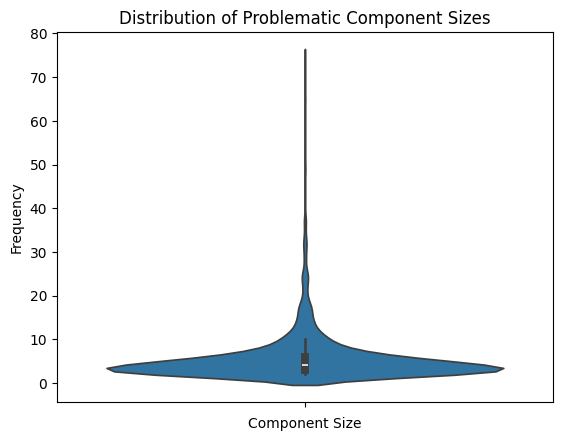

In [111]:
sns.violinplot(ProblematicCompoLenDist)
plt.xlabel("Component Size")
plt.ylabel("Frequency")
plt.title("Distribution of Problematic Component Sizes")

In [112]:
ProblematicCompoClassDist = [len(value["classes"]) for key, value in ComponentIndex.items() if value["status"] == "problematic"]

Text(0.5, 1.0, 'Distribution of Number of Classes in Problematic Component Sizes')

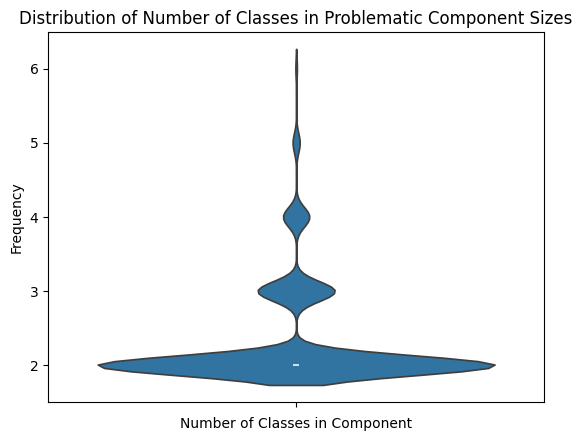

In [113]:
sns.violinplot(ProblematicCompoClassDist)
plt.xlabel("Number of Classes in Component")
plt.ylabel("Frequency")
plt.title("Distribution of Number of Classes in Problematic Component Sizes")

In [118]:
def ConcateComponentsBy(CompDict, OriginalGraph, Minsize = None, MinClassNumber = None):
    if Minsize is None and MinClassNumber is None:
        raise ValueError("At least one of Minsize or MinClassNumber must be provided. Both cannot be None.")
    elif Minsize is not None and MinClassNumber is not None:
        raise ValueError("Only one of Minsize or MinClassNumber can be provided. Both cannot be set at the same time.")
    
    ConcateComponents = set()
    for key, value in CompDict.items():
        if Minsize is not None and value["len"] >= Minsize and value["status"] == "problematic":
            ConcateComponents = ConcateComponents.union(value["component"])

        elif MinClassNumber is not None and len(value["classes"]) == MinClassNumber:
            ConcateComponents = ConcateComponents.union(value["component"])            
    return OriginalGraph.subgraph(ConcateComponents),ConcateComponents

In [115]:
ProblematicSubGraph, ConcateComponents = ConcateComponentsBy(ComponentIndex, SequenceSimilarityGraph, MinClassNumber=2)

In [116]:
ProblematicSubGraph.nodes

NodeView(('HMD_10772', 'NCRD_17315', 'NCRD_1834', 'NCRD_10889', 'NDARO_9644', 'NCRD_13836', 'NCRD_12507', 'CARD_1880', 'NCRD_13579', 'NCRD_13068', 'NCRD_8760', 'HMD_6398', 'NCRD_6283', 'NDARO_1742', 'NCRD_5447', 'HMD_4397', 'NCRD_2296', 'NCRD_23261', 'NCRD_21110', 'NCRD_33229', 'NCRD_33649', 'HMD_12756', 'NCRD_22142', 'NCRD_32677', 'HMD_11624', 'RESFINDER_2902', 'NCRD_10081', 'HMD_3449', 'MEGARES_6698', 'HMD_3818', 'HMD_2143', 'NCRD_7581', 'NDARO_2316', 'NCRD_7423', 'NCRD_22440', 'MEGARES_4814', 'NCRD_10638', 'HMD_14920', 'HMD_11649', 'NCRD_26441', 'NCRD_25132', 'HMD_2674', 'NCRD_30667', 'NCRD_8130', 'HMD_2136', 'HMD_3266', 'MEGARES_2067', 'HMD_15353', 'NCRD_20494', 'NDARO_9812', 'RESFINDER_2549', 'HMD_15780', 'NCRD_6711', 'HMD_3831', 'NCRD_5746', 'NCRD_145', 'NCRD_31284', 'NDARO_1625', 'HMD_15618', 'NCRD_15619', 'NCRD_23182', 'NDARO_2626', 'HMD_14285', 'HMD_11430', 'MEGARES_1812', 'NCRD_19061', 'NCRD_6191', 'NCRD_15094', 'HMD_3195', 'NCRD_7929', 'MEGARES_1888', 'HMD_13254', 'HMD_8231'

In [117]:
# ComponentGraph = SequenceSimilarityGraph.subgraph(ProblematicComponents)

meu_layout = {
    "scalingRatio": 50.0,           # Aumente para afastar os grupos
    "gravity": 0.2,                 # Reduza para não amontoar no centro
    "repulsion": 0.8,               # Aumente para afastar os nós
    # "outboundAttractionDistribution": True, # Empurra hubs para fora
    # "barnesHutOptimize": True,      # Essencial para seus 70k nós
    # "linLogMode": True              # Melhora a definição de clusters biológicos 
}
Sigma(
    ProblematicSubGraph, 
    node_size  = ProblematicSubGraph.degree(), 
    node_color =  [ProblematicSubGraph.nodes[n].get("Drug Class") for n in ProblematicSubGraph.nodes()],
    # node_metrics={"community": "louvain"},

    default_edge_type = "curve",
    layout_settings=meu_layout,
    # start_layout=20,
    )

Sigma(nx.Graph with 17,890 nodes and 14,787 edges)